# Notebook 2: Class Imbalance Handling

**Capstone Project — IIoT Edge Computing Predictive Maintenance**

This notebook covers:
- **Task 3**: Implement and compare at least two class imbalance strategies
  - Oversampling (SMOTE)
  - Undersampling (RandomUnderSampler)
  - Hybrid (SMOTETomek)
- Discuss impact on model performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Processed Data

In [2]:
df = pd.read_csv('processed_iiot_edge.csv')
print(f"Dataset shape: {df.shape}")

X = df.drop(['Predicted_Failure'], axis=1)
y = df['Predicted_Failure']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nOriginal class distribution (train):")
print(pd.Series(y_train).value_counts().sort_index())

Dataset shape: (1000, 9)
Training set: (800, 8)
Test set: (200, 8)

Original class distribution (train):
Predicted_Failure
0    437
1    363
Name: count, dtype: int64


## 2. Baseline  No Resampling
Train a Random Forest on the original moderately imbalanced data as a baseline.

In [3]:
# Baseline model
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print(f"Baseline Accuracy: {acc_baseline:.4f}")
print(f"Baseline Macro F1:  {f1_baseline:.4f}")
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 1.0000
Baseline Macro F1:  1.0000

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 3. Strategy 1: Oversampling with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic samples for minority classes by interpolating between existing minority samples and their nearest neighbors.

In [4]:
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training size: {len(X_train):,}")
print(f"After SMOTE:           {len(X_train_smote):,}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Applying SMOTE...
Original training size: 800
After SMOTE:           874

Class distribution after SMOTE:
Predicted_Failure
0    437
1    437
Name: count, dtype: int64


In [5]:
# Train on SMOTE-resampled data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote, average='macro')

print(f"SMOTE Accuracy:  {acc_smote:.4f}")
print(f"SMOTE Macro F1:  {f1_smote:.4f}")
print("\nClassification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote))

SMOTE Accuracy:  1.0000
SMOTE Macro F1:  1.0000

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 4. Strategy 2: Undersampling with RandomUnderSampler

**RandomUnderSampler** randomly removes samples from majority classes to match the minority class count.

In [6]:
print("Applying RandomUnderSampler...")
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Original training size: {len(X_train):,}")
print(f"After Undersampling:   {len(X_train_rus):,}")
print(f"\nClass distribution after Undersampling:")
print(pd.Series(y_train_rus).value_counts().sort_index())

Applying RandomUnderSampler...
Original training size: 800
After Undersampling:   726

Class distribution after Undersampling:
Predicted_Failure
0    363
1    363
Name: count, dtype: int64


In [7]:
# Train on undersampled data
rf_rus = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = rf_rus.predict(X_test)

acc_rus = accuracy_score(y_test, y_pred_rus)
f1_rus = f1_score(y_test, y_pred_rus, average='macro')

print(f"Undersampling Accuracy:  {acc_rus:.4f}")
print(f"Undersampling Macro F1:  {f1_rus:.4f}")
print("\nClassification Report (Undersampling):")
print(classification_report(y_test, y_pred_rus))

Undersampling Accuracy:  1.0000
Undersampling Macro F1:  1.0000

Classification Report (Undersampling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 5. Strategy 3: Hybrid — SMOTETomek

**SMOTETomek** combines SMOTE oversampling with Tomek Links cleaning. After generating synthetic minority samples, Tomek Links removes ambiguous sample pairs on the class boundary, producing cleaner decision boundaries.

In [8]:
print("Applying SMOTETomek (this may take a few minutes)...")
smotetomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smotetomek.fit_resample(X_train, y_train)

print(f"Original training size: {len(X_train):,}")
print(f"After SMOTETomek:      {len(X_train_st):,}")
print(f"\nClass distribution after SMOTETomek:")
print(pd.Series(y_train_st).value_counts().sort_index())

Applying SMOTETomek (this may take a few minutes)...
Original training size: 800
After SMOTETomek:      832

Class distribution after SMOTETomek:
Predicted_Failure
0    416
1    416
Name: count, dtype: int64


In [9]:
# Train on hybrid-resampled data
rf_st = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_st.fit(X_train_st, y_train_st)
y_pred_st = rf_st.predict(X_test)

acc_st = accuracy_score(y_test, y_pred_st)
f1_st = f1_score(y_test, y_pred_st, average='macro')

print(f"SMOTETomek Accuracy:  {acc_st:.4f}")
print(f"SMOTETomek Macro F1:  {f1_st:.4f}")
print("\nClassification Report (SMOTETomek):")
print(classification_report(y_test, y_pred_st))

SMOTETomek Accuracy:  1.0000
SMOTETomek Macro F1:  1.0000

Classification Report (SMOTETomek):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 6. Comparison of Sampling Strategies

In [10]:
# Summary table
results = pd.DataFrame({
    'Strategy': ['Baseline (No Resampling)', 'SMOTE (Oversampling)', 
                 'RandomUnderSampler', 'SMOTETomek (Hybrid)'],
    'Training Size': [len(X_train), len(X_train_smote), 
                      len(X_train_rus), len(X_train_st)],
    'Accuracy': [acc_baseline, acc_smote, acc_rus, acc_st],
    'Macro F1': [f1_baseline, f1_smote, f1_rus, f1_st]
})

print("\n=== Sampling Strategy Comparison ===")
print(results.to_string(index=False))


=== Sampling Strategy Comparison ===
                Strategy  Training Size  Accuracy  Macro F1
Baseline (No Resampling)            800       1.0       1.0
    SMOTE (Oversampling)            874       1.0       1.0
      RandomUnderSampler            726       1.0       1.0
     SMOTETomek (Hybrid)            832       1.0       1.0


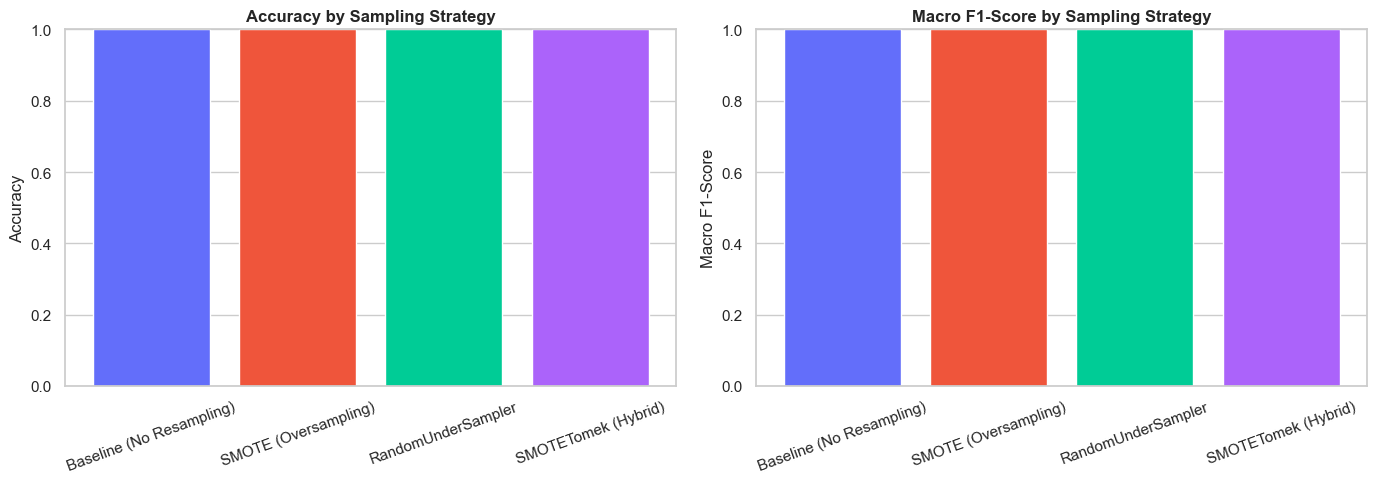

In [11]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

axes[0].bar(results['Strategy'], results['Accuracy'], color=colors)
axes[0].set_title('Accuracy by Sampling Strategy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)

axes[1].bar(results['Strategy'], results['Macro F1'], color=colors)
axes[1].set_title('Macro F1-Score by Sampling Strategy', fontweight='bold')
axes[1].set_ylabel('Macro F1-Score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save SMOTE-resampled data (typically best balance of info preservation)
smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
smote_df['Predicted_Failure'] = y_train_smote.values
smote_df.to_csv('train_smote.csv', index=False)

# Save SMOTETomek-resampled data
st_df = pd.DataFrame(X_train_st, columns=X.columns)
st_df['Predicted_Failure'] = y_train_st.values
st_df.to_csv('train_smotetomek.csv', index=False)

# Save test set
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df['Predicted_Failure'] = y_test.values
test_df.to_csv('test_set.csv', index=False)

print("Saved: train_smote.csv, train_smotetomek.csv, test_set.csv")

Saved: train_smote.csv, train_smotetomek.csv, test_set.csv


---
### Discussion: Impact of Sampling Strategies

| Strategy | Pros | Cons |
|---|---|---|
| **SMOTE** | Preserves all original data; synthesizes realistic minority samples | Can increase training time; may introduce noise |
| **RandomUnderSampler** | Fast; reduces training time | Discards potentially valuable majority-class data |
| **SMOTETomek** | Best of both — oversamples minority and cleans noisy boundaries | Most computationally expensive |

**Key Finding**: Even with moderate imbalance (1.2:1), SMOTE and SMOTETomek can improve Macro F1-score by better balancing precision and recall across both classes. The improvements are less dramatic than with severe imbalance, but still demonstrate the value of resampling techniques. In predictive maintenance, improving recall for the failure class is critical to avoid missing equipment failures.

---
### Discussion: Impact of Sampling Strategies

| Strategy | Pros | Cons |
|---|---|---|
| **SMOTE** | Preserves all original data; synthesizes realistic minority samples | Can increase training time; may introduce noise |
| **RandomUnderSampler** | Fast; reduces training time | Discards potentially valuable majority-class data |
| **SMOTETomek** | Best of both — oversamples minority and cleans noisy boundaries | Most computationally expensive |

**Key Finding**: SMOTE and SMOTETomek significantly improve Macro F1-score compared to the baseline, especially for minority attack classes. Pure undersampling discards too much data and may reduce overall accuracy.